#### Creating the shp file

In [1]:
import geopandas as gpd
from shapely.geometry import Point

data = [
    {'name': 'Point A', 'geometry': Point(1,1)},
    {'name': 'Point B', 'geometry': Point(2,2)},
    {'name': 'Point C', 'geometry': Point(3,3)}
]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry='geometry')

# Save the GeoDataFrame to a shape file
gdf.to_file('points.shp')

print("Shapefile created successfully")

Shapefile created successfully


d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


#### Reading a shape file

      name     geometry
0  Point A  POINT (1 1)
1  Point B  POINT (2 2)
2  Point C  POINT (3 3)


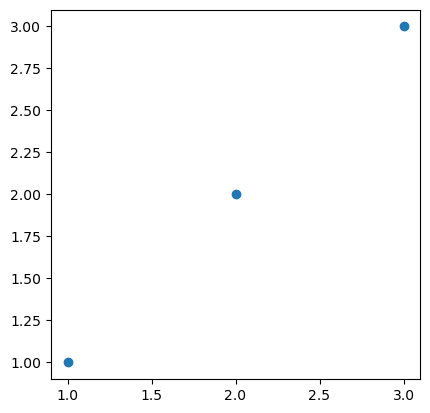

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

#Read the shape file
gdf = gpd.read_file('points.shp')

#Display the GeoDataFrame
print(gdf)

# Plot the points
gdf.plot()
plt.show()

#### Exploring the GeoDataFrame

In [4]:
# Display the GeoDataFrame
print(gdf.head())
      
#Display the geometry column
print(gdf.geometry)

#Display the CRS (Coordinate Reference System)
print(gdf.crs)

      name     geometry
0  Point A  POINT (1 1)
1  Point B  POINT (2 2)
2  Point C  POINT (3 3)
0    POINT (1 1)
1    POINT (2 2)
2    POINT (3 3)
Name: geometry, dtype: geometry
None


#### Adding Attributes and Saving Changes

In [5]:
# Add a new column
gdf['Description'] = ["First Point", 'Second Point', 'Third Point']

# Save the updated GeoDateFrame to a new shape file
gdf.to_file('points_updated.shp')

print("Updated shapefile created successfully!")


Updated shapefile created successfully!


C:\Users\shrestha\AppData\Local\Temp\ipykernel_22024\3997906992.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('points_updated.shp')
d:\anaconda\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Description' to 'Descriptio'
  ogr_write(


#### Ploting the data

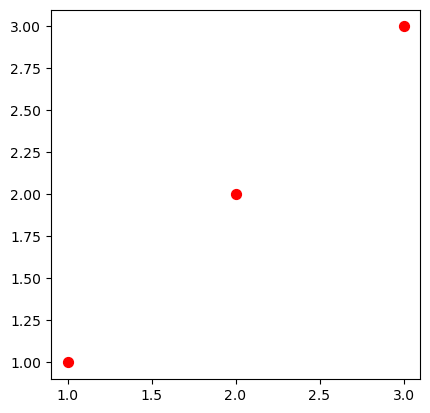

In [6]:
# Plot the points
gdf.plot(marker='o', color='red', markersize=50)

#show the plot
plt.show()

# Understanding the Shapefile Components
## A shapefile consists of several components:

    .shp: The file that stores the geometry.
    .shx: The index file for the geometry.
    .dbf: The file that stores attribute data.
    .prj: The file that stores projection information (optional).

## .shp: The Geometry File
The .shp file is the core component of a shapefile. It stores the geometric data, such as points, lines, and polygons. This file contains the spatial representation of the features in the dataset.

    Structure: The .shp file is a binary file that contains the geometric shapes (e.g., coordinates of points, vertices of lines and polygons).
    Purpose: It defines the spatial data that you see on a map.
    Example: If you have a shapefile representing cities, the .shp file would store the coordinates of each city.

## .shx: The Index File
The .shx file is an index file that helps in quickly locating the geometry records within the .shp file. It is a binary file that contains offsets and lengths of the geometry records.

    Structure: The .shx file contains a header and a series of index records. Each index record points to the location of a geometry record in the .shp file.
    Purpose: It speeds up the reading process by allowing the software to quickly jump to specific records without scanning the entire .shp file.
    Example: When you zoom in on a map, the software uses the .shx file to quickly find the relevant geometry records in the .shp file.

## .dbf: The Attribute File
The .dbf file is a dBase table that stores the attribute data associated with the geometric features in the .shp file. Each row in the .dbf file corresponds to a feature in the .shp file.

    Structure: The .dbf file is a standard dBase IV table format. It contains columns for each attribute and rows for each feature.
    Purpose: It stores non-spatial data associated with the geometric features, such as names, descriptions, or numerical values.
    Example: If you have a shapefile representing cities, the .dbf file might contain columns for city names, population, and other attributes.

## .prj: The Projection File (Optional)
The .prj file is a plain text file that stores the coordinate reference system (CRS) information for the shapefile. This file is optional but highly recommended for proper spatial analysis and visualization.

    Structure: The .prj file contains a Well-Known Text (WKT) representation of the CRS.
    Purpose: It defines the spatial reference system used by the shapefile, such as geographic coordinates (latitude/longitude) or projected coordinates (e.g., UTM).
    Example: If your shapefile uses the WGS 84 / UTM zone 33N projection, the .prj file will contain the WKT string that describes this projection.

## Additional Files (Optional)
While the .shp, .shx, and .dbf files are essential, there are other optional files that can be part of a shapefile dataset:

    .sbn and .sbx: Spatial index files that improve the performance of spatial queries.
    .xml: Metadata file that provides additional information about the dataset.
    .cpg: Character set description file that specifies the encoding used for text fields in the .dbf file.